# Phase 0: Feasibility

**Question:** can a model predict whether a detected California wildfire escalates within 24h better than a persistence rule ("it grew recently, so it keeps growing")?

Pipeline: FIRMS VIIRS detections → per-pass DBSCAN clusters → tracked fires (`fire_id`) → versioned labels → point-in-time features + Open-Meteo forecasts → baseline vs XGBoost on a time split.

All logic lives in `wildfire/`; this notebook only drives it.

In [1]:
import sys; sys.path.insert(0, "..")
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold
from sklearn.metrics import average_precision_score, brier_score_loss
from sklearn.calibration import calibration_curve
from xgboost import XGBClassifier

from wildfire import firms, fires, labels, weather, features

PROC = Path("../data/processed"); PROC.mkdir(parents=True, exist_ok=True)

## 1. Detections
Pulled once and cached as raw parquet; re-running skips anything already downloaded.

In [2]:
firms.pull()
det = firms.load()
# why: low-confidence VIIRS pixels are mostly sun glint and hot surfaces, not fire.
# Dropping them here keeps them out of clustering, labels and features alike.
det = det[det["confidence"] != "l"]
print(len(det), "detections"); det.groupby(det.time.dt.year).size()

VIIRS_NOAA20_SP 2022-06-01 +5d: 222 detections
VIIRS_NOAA20_SP 2022-06-06 +5d: 254 detections
VIIRS_NOAA20_SP 2022-06-11 +5d: 392 detections
VIIRS_NOAA20_SP 2022-06-16 +5d: 398 detections
VIIRS_NOAA20_SP 2022-06-21 +5d: 313 detections
VIIRS_NOAA20_SP 2022-06-26 +5d: 397 detections
VIIRS_NOAA20_SP 2022-07-01 +5d: 410 detections
VIIRS_NOAA20_SP 2022-07-06 +5d: 675 detections
VIIRS_NOAA20_SP 2022-07-11 +5d: 844 detections
VIIRS_NOAA20_SP 2022-07-16 +5d: 291 detections
VIIRS_NOAA20_SP 2022-07-21 +5d: 1075 detections
VIIRS_NOAA20_SP 2022-07-26 +5d: 885 detections
VIIRS_NOAA20_SP 2022-07-31 +5d: 1503 detections
VIIRS_NOAA20_SP 2022-08-05 +5d: 898 detections
VIIRS_NOAA20_SP 2022-08-10 +5d: 763 detections
VIIRS_NOAA20_SP 2022-08-15 +5d: 563 detections
VIIRS_NOAA20_SP 2022-08-20 +5d: 571 detections
VIIRS_NOAA20_SP 2022-08-25 +5d: 1265 detections
VIIRS_NOAA20_SP 2022-08-30 +5d: 1528 detections
VIIRS_NOAA20_SP 2022-09-04 +5d: 2505 detections
VIIRS_NOAA20_SP 2022-09-09 +5d: 2251 detections
VIIRS_N

94089 detections


time
2022    23786
2023    28594
2024    41709
dtype: int64

## 2. Fires: cluster each pass, track across passes

In [3]:
if (PROC / "tracked.parquet").exists():
    tracked, merges = pd.read_parquet(PROC / "tracked.parquet"), pd.read_parquet(PROC / "merges.parquet")
else:
    tracked, merges = fires.track(det)
    tracked.to_parquet(PROC / "tracked.parquet"); merges.to_parquet(PROC / "merges.parquet")
summary = fires.summarize(tracked)
span = summary.groupby("fire_id")["bin"].agg(lambda b: (b.max() - b.min()).days)
print(summary.fire_id.nunique(), "fires,", len(merges), "merges,", len(summary), "fire-passes")
span.describe()

9231 fires, 191 merges, 22003 fire-passes


count    9231.000000
mean        1.558119
std         6.888562
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max       181.000000
Name: bin, dtype: float64

Sources that stay active for months but never grow are usually not wildfires. They're industrial heat sources such as refineries, flares and power plants. They're dropped here, and this is listed as a known issue. Real long fires (the Park Fire burned for two months) are kept because they're large.

In [4]:
max_area = summary.groupby("fire_id")["area_km2"].max()
static = span[(span > 60) & (max_area.reindex(span.index) < 1)].index
summary = summary[~summary.fire_id.isin(static)]
print(len(static), "static heat sources dropped")

20 static heat sources dropped


## 3. Features and labels
Features come from `features.build`, the same function the Phase 4 scoring job will call. Labels are built for several thresholds `x`.

In [5]:
hourly = weather.hourly_for(summary)
feat = features.build(summary, hourly)
X_SWEEP = [0.25, 0.5, 1.0]
data = {x: feat.merge(labels.label(summary, merges, x=x)[["fire_id", "bin", "escalated", "label_version"]], on=["fire_id", "bin"])
        for x in X_SWEEP}
for x, d in data.items():
    print(d.label_version.iat[0], len(d), "rows, base rate", round(d.escalated.mean(), 3))

weather 0/1443
weather 100/1443


weather 200/1443


weather 300/1443
weather 400/1443


weather 500/1443


weather 600/1443
weather 700/1443


weather 800/1443
weather 900/1443


weather 1000/1443
weather 1100/1443


weather 1200/1443
weather 1300/1443


weather 1400/1443


h=24h|x=0.25|count_or_frp|occluded=drop 17402 rows, base rate 0.19
h=24h|x=0.5|count_or_frp|occluded=drop 17402 rows, base rate 0.156
h=24h|x=1.0|count_or_frp|occluded=drop 17402 rows, base rate 0.114


## 4. Evaluation
- **Split by time:** train on 2022–2023, test on 2024. This mirrors deployment: predicting the future.
- **Tuning** uses `GroupKFold` by `fire_id`, so one fire never appears in both train and validation.
- **Baseline:** logistic regression on the 24h growth features only (persistence), which is calibrated by construction.
- **Metrics:** PR-AUC, because classes are imbalanced, and Brier score plus a reliability curve, because the API returns a probability.

In [6]:
BASE = ["growth_n_24h", "growth_frp_24h"]
GRID = [dict(max_depth=d, learning_rate=lr) for d in (3, 5) for lr in (0.03, 0.1)]

def tune(tr):
    # why: grouped CV. A fire has many correlated rows; letting one fire span folds leaks.
    cv = GroupKFold(n_splits=5)
    def score(p):
        s = []
        for a, b in cv.split(tr, groups=tr.fire_id):
            m = XGBClassifier(n_estimators=300, subsample=0.8, colsample_bytree=0.8, **p)
            m.fit(tr.iloc[a][features.FEATURES], tr.iloc[a].escalated)
            s.append(average_precision_score(tr.iloc[b].escalated, m.predict_proba(tr.iloc[b][features.FEATURES])[:, 1]))
        return np.mean(s)
    return max(GRID, key=score)

results, preds = [], {}
for x, d in data.items():
    tr, te = d[d.bin.dt.year < 2024], d[d.bin.dt.year == 2024]
    base = LogisticRegression().fit(tr[BASE], tr.escalated)
    params = tune(tr)
    model = XGBClassifier(n_estimators=300, subsample=0.8, colsample_bytree=0.8, **params).fit(tr[features.FEATURES], tr.escalated)
    p_base, p_xgb = base.predict_proba(te[BASE])[:, 1], model.predict_proba(te[features.FEATURES])[:, 1]
    preds[x] = (te, p_base, p_xgb, model)
    results.append(dict(x=x, test_rows=len(te), base_rate=te.escalated.mean(),
                        prauc_baseline=average_precision_score(te.escalated, p_base),
                        prauc_xgb=average_precision_score(te.escalated, p_xgb),
                        brier_baseline=brier_score_loss(te.escalated, p_base),
                        brier_xgb=brier_score_loss(te.escalated, p_xgb), params=params))
results = pd.DataFrame(results); results

,x,test_rows,base_rate,prauc_baseline,prauc_xgb,brier_baseline,brier_xgb,params
0,0.25,5824,0.177198,0.282909,0.409120,0.141913,0.126266,"{'max_depth': 5, 'learning_rate': 0.03}"
1,0.50,5824,0.144918,0.237446,0.342615,0.121165,0.110757,"{'max_depth': 5, 'learning_rate': 0.03}"
2,1.00,5824,0.107143,0.184079,0.293453,0.093673,0.086367,"{'max_depth': 5, 'learning_rate': 0.03}"


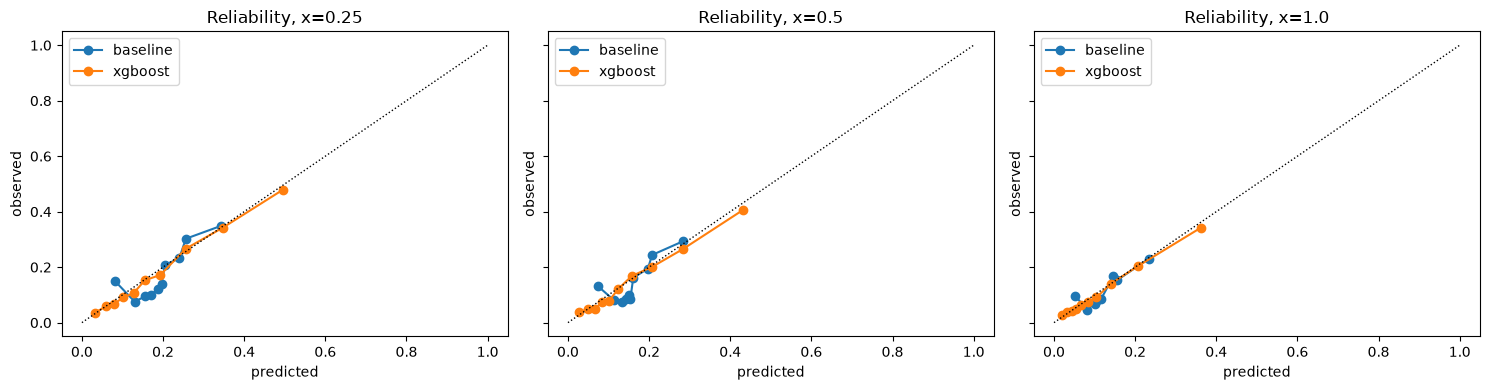

In [7]:
fig, axes = plt.subplots(1, len(X_SWEEP), figsize=(5 * len(X_SWEEP), 4), sharey=True)
for ax, (x, (te, p_base, p_xgb, _)) in zip(axes, preds.items()):
    for name, p in [("baseline", p_base), ("xgboost", p_xgb)]:
        fr, mp = calibration_curve(te.escalated, p, n_bins=10, strategy="quantile")
        ax.plot(mp, fr, marker="o", label=name)
    ax.plot([0, 1], [0, 1], "k:", lw=1); ax.set(title=f"Reliability, x={x}", xlabel="predicted", ylabel="observed")
    ax.legend()
plt.tight_layout()

### Feature importance (sanity check)
Growth and weather should matter. If `month` or `age_h` dominate, the model is probably learning a data artifact instead.

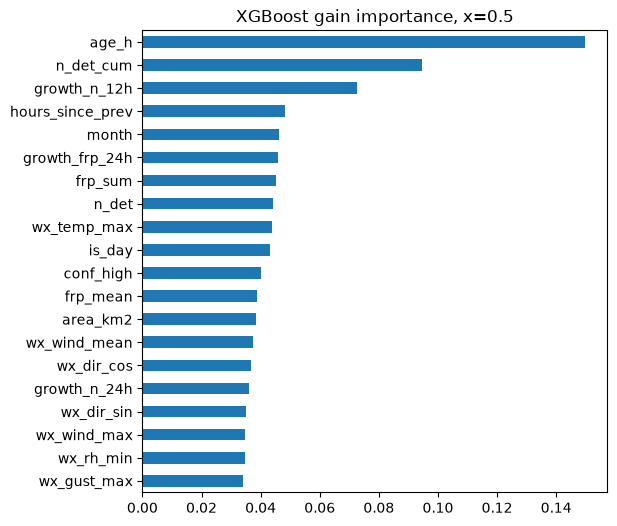

In [8]:
x_main = 0.5
imp = pd.Series(preds[x_main][3].feature_importances_, index=features.FEATURES).sort_values()
imp.plot.barh(figsize=(6, 6), title=f"XGBoost gain importance, x={x_main}");

### Does the model's advantage hold on bigger fires?
Most rows are tiny fires, and for those "doubling" can mean going from 1 hot pixel to 2. Scoring separately by fire size shows whether the model has only learned "new tiny fires flicker".

In [9]:
te, p_base, p_xgb, _ = preds[x_main]
print("share of test rows with a single detection:", round((te.n_det == 1).mean(), 2))
pd.DataFrame([dict(min_detections=lo, rows=int(m.sum()), base_rate=te.escalated[m].mean(),
                   prauc_baseline=average_precision_score(te.escalated[m], p_base[m]),
                   prauc_xgb=average_precision_score(te.escalated[m], p_xgb[m]))
              for lo in (1, 3, 5, 10) for m in [(te.n_det >= lo).to_numpy()]]).round(3)

share of test rows with a single detection: 0.62


,min_detections,rows,base_rate,prauc_baseline,prauc_xgb
0,1,5824,0.145,0.237,0.343
1,3,1293,0.166,0.211,0.278
2,5,779,0.214,0.237,0.293
3,10,466,0.223,0.245,0.266


## 5. Sanity check against official fire records
Everything above rests on our tracked `fire_id`s being real fires. Here we compare them with the 10 largest 2024 California fires in NIFC's WFIGS perimeter dataset:
- **Found:** did we detect it within 2 days of the official discovery date?
- **Fragmentation:** how many of our `fire_id`s have detections inside the official final perimeter? 1 is ideal. Many means the tracker split one fire into several, which would make growth look like new fires.
- **Main-ID share:** the share of in-perimeter detections that belong to the single biggest `fire_id`.

In [10]:
import json, requests
from shapely.geometry import shape, Point
from shapely import contains_xy

WFIGS = "https://services3.arcgis.com/T4QMspbfLg3qTGWY/arcgis/rest/services/WFIGS_Interagency_Perimeters/FeatureServer/0/query"
perim_path = Path("../data/raw/wfigs_ca_2024_top10.geojson")
if not perim_path.exists():
    r = requests.get(WFIGS, params=dict(
        where="attr_POOState='US-CA' AND attr_FireDiscoveryDateTime >= TIMESTAMP '2024-06-01 00:00:00' "
              "AND attr_FireDiscoveryDateTime < TIMESTAMP '2024-12-01 00:00:00'",
        outFields="poly_IncidentName,poly_GISAcres,attr_FireDiscoveryDateTime",
        orderByFields="poly_GISAcres DESC", resultRecordCount=10, outSR=4326, f="geojson"), timeout=120)
    r.raise_for_status(); perim_path.write_text(r.text)
perims = json.loads(perim_path.read_text())["features"]

rows = []
for f in perims:
    a, geom = f["properties"], shape(f["geometry"])
    found = pd.Timestamp(a["attr_FireDiscoveryDateTime"], unit="ms", tz="UTC")
    # from 2 days before discovery: earlier, separate fires can burn inside the same final perimeter
    inside = tracked[(tracked.time >= found - pd.Timedelta("2D")) & contains_xy(geom, tracked.lon.to_numpy(), tracked.lat.to_numpy())]
    ids = inside.fire_id.value_counts()
    rows.append(dict(fire=a["poly_IncidentName"], acres=round(a["poly_GISAcres"]), discovered=found.date(),
                     first_detected=inside.time.min().date() if len(inside) else None,
                     lag_days=round((inside.time.min() - found).total_seconds() / 86400, 1) if len(inside) else None,
                     detections=len(inside), fire_ids=len(ids),
                     main_id_share=round(ids.iloc[0] / len(inside), 2) if len(inside) else None))
check = pd.DataFrame(rows); check

,fire,acres,discovered,first_detected,lag_days,detections,fire_ids,main_id_share
0,PARK,429603,2024-07-24,2024-07-24,0.0,8313,16,1.00
1,BOREL,59289,2024-07-24,2024-07-24,0.0,1540,2,1.00
2,BRIDGE,54862,2024-09-08,2024-09-09,0.5,1633,6,0.99
3,LINE,43976,2024-09-06,2024-09-06,0.3,1052,6,0.80
4,Lake,38610,2024-07-05,2024-07-06,0.5,1202,1,1.00
5,TROUT,23822,2024-07-13,2024-07-13,0.2,2538,6,0.99
6,Airport,23519,2024-09-09,2024-09-09,0.0,607,1,1.00
7,Mountain,20630,2024-11-06,2024-11-06,0.2,261,2,0.90
8,SITES,19195,2024-06-17,2024-06-17,0.1,331,3,0.57
9,Boone,17600,2024-09-03,2024-09-03,0.1,428,1,1.00


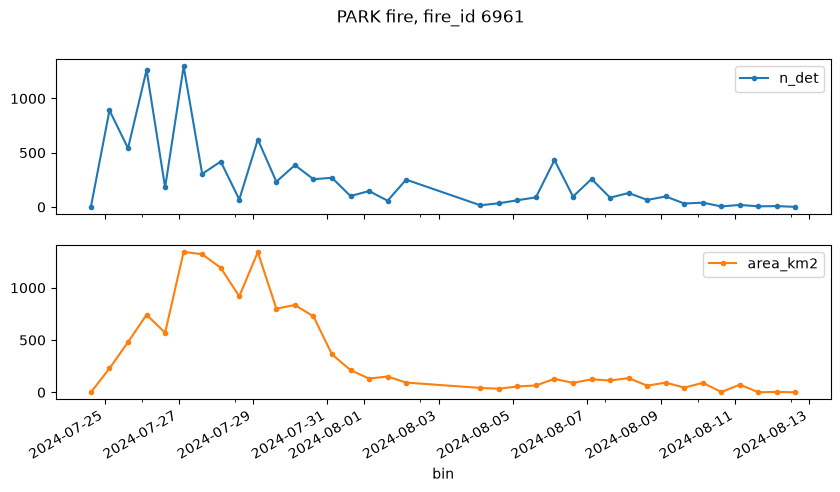

In [11]:
# growth curve of the biggest fire: detections per pass for its main fire_id
top = perims[0]; geom = shape(top["geometry"])
inside = tracked[(tracked.bin.dt.year == 2024) & contains_xy(geom, tracked.lon.to_numpy(), tracked.lat.to_numpy())]
main = inside.fire_id.value_counts().index[0]
curve = summary[summary.fire_id == main].set_index("bin")[["n_det", "area_km2"]]
curve.plot(subplots=True, figsize=(10, 5), marker=".", title=f"{top['properties']['poly_IncidentName']} fire, fire_id {main}");

## 6. Decision: conditional GO

**Result (2024 test set, x = 0.5):** XGBoost PR-AUC is **0.34** against 0.24 for the persistence baseline, with a base rate of 0.145. Brier score improves from 0.121 to 0.111, and both models are well calibrated. The model wins at every threshold x, and the gap exceeds the planned ≥0.05 bar. **Tracking** passes the check against official records: all 10 of the largest 2024 fires were found within half a day of discovery, and 8 of 10 kept ≥90% of their detections under a single `fire_id`.

**But:** 62% of rows are single-detection fires, and much of the lift comes from them. On fires with ≥10 detections, XGBoost only reaches 0.27 against a baseline of 0.25 and a base rate of 0.22. `age_h` is the top feature, which is consistent with "new tiny fires flicker" being a large part of what the model has learned.

**Chosen label for now:** `h=24h|x=0.5|count_or_frp|occluded=drop`.

**Before Phase 1, fix the label on small fires:**
1. Require a minimum size to be labelled (e.g. ≥3 detections at T), or add an absolute growth floor (e.g. +5 detections *and* +50%).
2. Re-check whether the weather features carry signal on the larger fires. That's where escalation matters and where wind should dominate.

**Known issues**
- Weather uses stitched historical forecasts, whose lead time is shorter than a real 24h forecast, so offline weather is slightly optimistic.
- Point-in-time assumption: FIRMS publishes a pass within ~3h. The archive has no ingestion timestamps to verify this.
- One satellite only (NOAA-20). SNPP was dropped because of outages that would fake shrinkage.
- Static heat sources are filtered with a rule (active more than 60 days and never larger than 1 km²), which is crude.
- The tracker occasionally splits a fire (SITES: 57% under its main ID) and creates small fragment IDs around big fires.